In [1]:
# 1 — Deep-sea container calls 2024–2025 with vessel operator, and coverage by terminal
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_berth"])
calls = calls[calls["navigation"] == "Longo Curso"].copy()
calls["year"] = calls["ts_berth"].dt.year
calls = calls[calls["year"].isin([2024, 2025])]
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()

tab = pd.read_csv(PROC / "tabela_completa.csv", usecols=["IMO", "Armador_Operador", "Aliança"]) \
        .rename(columns={"IMO": "imo", "Armador_Operador": "operator", "Aliança": "alliance"})
calls = calls.merge(tab, on="imo", how="left", validate="m:1")
calls["operator"] = calls["operator"].fillna("Unknown")
calls["alliance"] = calls["alliance"].fillna("Unknown")

prof25 = calls[calls["year"] == 2025].groupby("terminal").agg(n=("call_id", "size"), teu_per_call=("teu", "mean"))
TERMINALS = prof25.index[(prof25["n"] >= 100) & (prof25["teu_per_call"] >= 300)].tolist()
cc = calls[calls["terminal"].isin(TERMINALS)].copy()

def status(op):
    return "Unknown" if op == "Unknown" else ("Shared vessel" if op == "Múltiplos" else "Identified")
cc["id_status"] = cc["operator"].map(status)
cov = (cc.groupby(["terminal", "year", "id_status"])["teu"].sum().unstack("id_status").fillna(0))
cov = 100 * cov.div(cov.sum(axis=1), axis=0)
cov = cov.unstack("year").round(1)
cov.index = [t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:22] for t in cov.index]
print(f"Container terminals in scope: {len(TERMINALS)} | calls: {len(cc):,}")
print("\nShare of TEU by identification status (%):")
print(cov.sort_values(("Identified", 2025), ascending=False).to_string())

Container terminals in scope: 15 | calls: 10,942

Share of TEU by identification status (%):
id_status                                   Identified       Shared vessel       Unknown      
year                                              2024  2025          2024  2025    2024  2025
Portonave - Termin | Portonave - Terminais        60.7  89.1           6.5   6.6    32.8   4.3
Paranaguá | TCP                                   66.1  88.9           7.9   7.5    26.0   3.6
Porto Itapoá Termi | Porto Itapoá Terminais       68.6  88.0           4.1   5.7    27.3   6.4
Santos | Cais da BTP (SSZ 41) -                   62.6  87.4           5.9   6.9    31.5   5.6
Santos | Cais da Santos Brasil                    70.7  87.4           2.2   7.3    27.0   5.3
Rio de Janeiro | ICTSI                            55.3  86.1           5.9   9.1    38.8   4.8
Rio de Janeiro | Multi-Rio                        46.2  81.5           9.3   9.0    44.5   9.4
Salvador | TECON Área 2                           51

In [2]:
# 2 — Carrier concentration by terminal, TEU-weighted, with bounds for unidentified TEU
UNID = {"Unknown", "Múltiplos"}

def concentration(df, key):
    rows = []
    for (k, y), g in df.groupby([key, "year"]):
        tot = g["teu"].sum()
        s = g.groupby("operator")["teu"].sum()
        known = s.drop([o for o in UNID if o in s.index])
        sh_id = 100 * known / known.sum()
        sh_tot = 100 * known / tot
        unid_pct = 100 - sh_tot.sum()
        hhi_min = (sh_tot ** 2).sum()
        hhi_max = hhi_min - sh_tot.max() ** 2 + (sh_tot.max() + unid_pct) ** 2
        rows.append({key: k, "year": y, "calls": len(g), "TEU_k": tot / 1e3, "identified_%": 100 - unid_pct,
                     "HHI": (sh_id ** 2).sum(), "HHI_min": hhi_min, "HHI_max": hhi_max,
                     "top_carrier": sh_id.idxmax(), "top_share_%": sh_id.max(),
                     "carriers_above_5%": int((sh_id > 5).sum())})
    out = pd.DataFrame(rows).set_index([key, "year"])
    band = lambda h: "high" if h > 2500 else ("moderate" if h >= 1500 else "low")
    out["class_2010"] = out["HHI"].map(band)
    out["uncertain"] = out["HHI_min"].map(band) != out["HHI_max"].map(band)
    return out

term = concentration(cc, "terminal")
term.index = term.index.set_levels([t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:22]
                                    for t in term.index.levels[0]], level=0)
show = term.unstack("year")
cols = [(c, y) for c in ["TEU_k", "identified_%", "HHI", "HHI_min", "HHI_max", "top_carrier", "top_share_%",
                         "carriers_above_5%", "class_2010", "uncertain"] for y in (2024, 2025)]
print(show[cols].sort_values(("TEU_k", 2025), ascending=False).round(0).to_string())

                                              TEU_k         identified_%           HHI         HHI_min         HHI_max         top_carrier          top_share_%       carriers_above_5%      class_2010           uncertain       
year                                           2024    2025         2024  2025    2024    2025    2024    2025    2024    2025        2024     2025        2024  2025              2024 2025       2024      2025      2024   2025
terminal                                                                                                                                                                                                                          
Santos | Cais da Santos Brasil               1645.0  1857.0         71.0  87.0  4714.0  2270.0  2359.0  1733.0  5987.0  2692.0      Maersk  CMA CGM        67.0  36.0                 4    5       high  moderate      True   True
Santos | Cais da BTP (SSZ 41) -              1501.0  1543.0         63.0  87.0  2718.0  3298

In [3]:
# 3 — Port level, alliance blocks and national (2025), plus the Santos Brasil shift
def port_group(t):
    p = t.split(" | ")[0]
    if "Santos" in p:
        return "Santos (BTP, Santos Brasil, DP World)"
    if p.startswith("Paranaguá"):
        return "Paranaguá (TCP, public quay)"
    if p.startswith("Rio de Janeiro"):
        return "Rio de Janeiro (Multi-Rio, ICTSI)"
    return p[:40]

cc["port_group"] = cc["terminal"].map(port_group)
c25 = cc[cc["year"] == 2025].copy()
cols = ["TEU_k", "identified_%", "HHI", "HHI_min", "HHI_max", "top_carrier", "top_share_%",
        "carriers_above_5%", "class_2010", "uncertain"]
print("2025 — by port:")
print(concentration(c25, "port_group")[cols].sort_values("TEU_k", ascending=False).round(0).to_string(), "\n")

print("Alliance values in the vessel table:", c25["alliance"].value_counts().to_dict(), "\n")
is_alliance = c25["alliance"].str.contains("Gemini|Ocean|Premier", na=False) & ~c25["operator"].isin(UNID)
c25_al = c25.assign(operator=np.where(is_alliance, c25["alliance"], c25["operator"]))
print("2025 — by port, alliance blocks (non-aligned carriers counted separately):")
print(concentration(c25_al, "port_group")[cols].sort_values("TEU_k", ascending=False).round(0).to_string(), "\n")

nat = pd.concat([concentration(c25.assign(scope="Brazil, carriers"), "scope"),
                 concentration(c25_al.assign(scope="Brazil, alliance blocks"), "scope")])
print("2025 — national:")
print(nat[cols].round(0).to_string(), "\n")

sb = cc[cc["terminal"].str.contains("Santos Brasil")]
sb_tab = (sb.groupby(["operator", "year"])["teu"].sum() / 1e3).unstack("year").fillna(0).round(0)
print("Santos Brasil — TEU by operator (thousands):")
print(sb_tab.sort_values(2025, ascending=False).head(10).to_string(), "\n")

sb25 = sb[sb["year"] == 2025].assign(period=lambda d: np.where(d["ts_berth"].dt.month <= 4, "Jan-Apr", "May-Dec"))
per = sb25[~sb25["operator"].isin(UNID)].groupby(["period", "operator"])["teu"].sum()
per = 100 * per / per.groupby(level=0).transform("sum")
print("Santos Brasil 2025 — share of identified TEU by operator, before and after May (%):")
print(per.unstack("period").fillna(0).sort_values("May-Dec", ascending=False).head(8).round(1).to_string())

2025 — by port:
                                                TEU_k  identified_%     HHI  HHI_min  HHI_max top_carrier  top_share_%  carriers_above_5% class_2010  uncertain
port_group                               year                                                                                                                  
Santos (BTP, Santos Brasil, DP World)    2025  4316.0          85.0  1911.0   1393.0   2392.0      Maersk         31.0                  5   moderate       True
Paranaguá (TCP, public quay)             2025  1453.0          84.0  2058.0   1469.0   2597.0      Maersk         34.0                  5   moderate       True
Porto Itapoá Terminais Portuários        2025  1441.0          88.0  3804.0   2943.0   4314.0      Maersk         58.0                  4       high      False
Portonave - Terminais Portuários de Nave 2025   848.0          89.0  1577.0   1253.0   1836.0         MSC         24.0                  6   moderate       True
Rio de Janeiro (Multi-Ri

In [4]:
# 4 — When did the switch happen, and where did Maersk's Santos volume go? (2025, by month)
s25 = cc[(cc["year"] == 2025) & cc["port_group"].str.startswith("Santos")].copy()
s25["term"] = np.select([s25["terminal"].str.contains("Santos Brasil"), s25["terminal"].str.contains("BTP")],
                        ["Santos Brasil", "BTP"], default="DP World")
s25["m"] = s25["ts_berth"].dt.month
OPS = ["Maersk", "CMA CGM", "MSC", "COSCO", "Hapag-Lloyd"]
sel = s25[s25["operator"].isin(OPS)]

monthly = (sel.groupby(["operator", "term", "m"])["teu"].sum() / 1e3).unstack("m").fillna(0).round(0)
print("TEU by operator, Santos terminal and month of 2025 (thousands; December up to 14 Dec only):")
print(monthly.to_string(), "\n")

sel = sel.assign(period=np.where(sel["m"] <= 4, "Jan-Apr", "May-Dec"))
months_in = {"Jan-Apr": 4, "May-Dec": 7.45}          # 14 Dec cut: May–Nov (7) + about half of December
avg = sel.groupby(["operator", "term", "period"])["teu"].sum().unstack("period") / 1e3
for p, n in months_in.items():
    avg[p] = avg[p] / n
avg["change"] = avg["May-Dec"] - avg["Jan-Apr"]
print("Average TEU per month (thousands), before and after May 2025:")
print(avg.round(1).to_string(), "\n")

tot = sel.groupby(["operator", "period"])["teu"].sum().unstack("period") / 1e3
for p, n in months_in.items():
    tot[p] = tot[p] / n
print("All three Santos terminals together — average TEU per month (thousands):")
print(tot.round(1).to_string())

TEU by operator, Santos terminal and month of 2025 (thousands; December up to 14 Dec only):
m                            1     2     3     4     5     6     7     8     9     10    11    12
operator    term                                                                                 
CMA CGM     BTP             6.0   5.0   9.0   2.0   4.0   2.0   5.0   3.0   5.0   1.0   4.0   2.0
            DP World       20.0   5.0   5.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
            Santos Brasil  23.0  15.0  20.0  32.0  68.0  45.0  57.0  65.0  70.0  72.0  59.0  61.0
COSCO       DP World        8.0  10.0   7.0   2.0   4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
            Santos Brasil  16.0  23.0  11.0  21.0  25.0  22.0  25.0  18.0  21.0  17.0  37.0  27.0
Hapag-Lloyd BTP             8.0  14.0   7.0  14.0  15.0  17.0   6.0  15.0  11.0   6.0  16.0   5.0
            DP World        6.0  10.0   7.0  10.0   9.0   8.0  14.0  10.0  15.0   9.0  12.0   3.0
            Santos Brasil 

Average TEU per month (thousands), before and after May 2025:
period                     Jan-Apr  May-Dec  change
operator    term                                   
CMA CGM     BTP                5.5      3.4    -2.1
            DP World           7.6      NaN     NaN
            Santos Brasil     22.4     66.9    44.5
COSCO       DP World           6.7      0.5    -6.2
            Santos Brasil     17.8     25.7     7.9
Hapag-Lloyd BTP               10.7     12.3     1.6
            DP World           8.2     10.7     2.5
            Santos Brasil      7.2      4.7    -2.5
MSC         BTP               39.7     58.4    18.6
            DP World           1.2      2.2     1.0
            Santos Brasil     11.4     14.0     2.6
Maersk      BTP               29.6     47.5    17.9
            DP World           8.5     36.4    28.0
            Santos Brasil     53.3     22.3   -31.0 

All three Santos terminals together — average TEU per month (thousands):
period       Jan-Apr  May-Dec
o

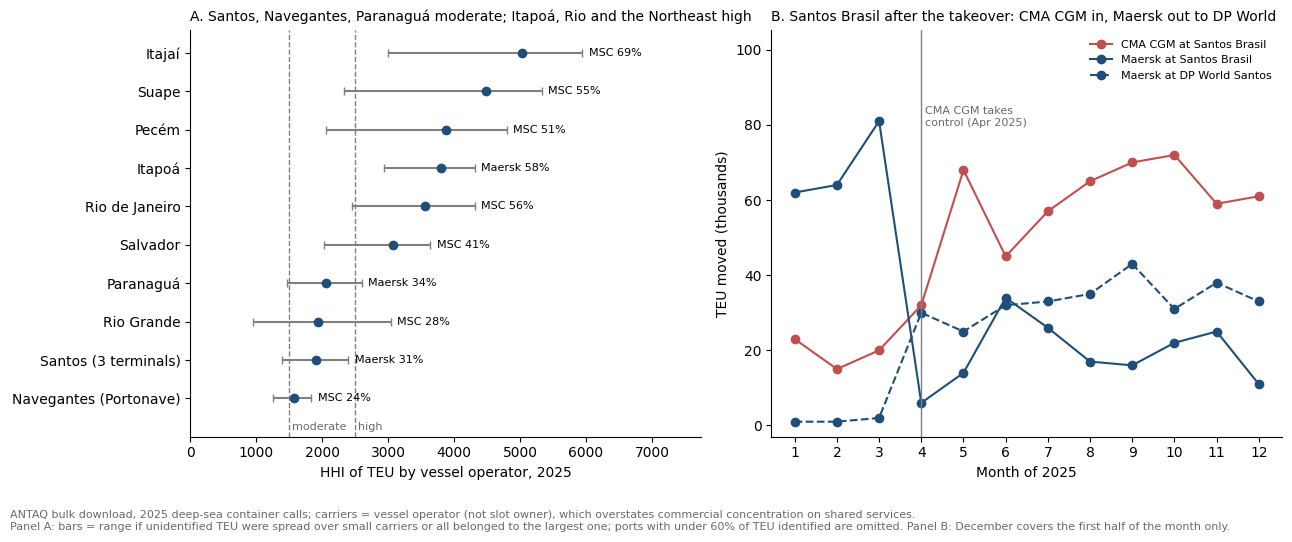

In [5]:
# 5 — Figure (fig15): concentration by port, and Santos after the CMA CGM takeover
FIG_DIR = BASE / "outputs" / "figures"
SHORT = {"Santos (BTP, Santos Brasil, DP World)": "Santos (3 terminals)",
         "Paranaguá (TCP, public quay)": "Paranaguá", "Porto Itapoá Terminais Portuários": "Itapoá",
         "Portonave - Terminais Portuários de Nave": "Navegantes (Portonave)",
         "Rio de Janeiro (Multi-Rio, ICTSI)": "Rio de Janeiro", "Terminal Portuário do Pecém": "Pecém"}

port25 = concentration(c25, "port_group").droplevel("year")
port25 = port25[port25["identified_%"] >= 60].sort_values("HHI")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — HHI by port with the range for unidentified TEU
yy = np.arange(len(port25))
ax1.errorbar(port25["HHI"], yy, xerr=[port25["HHI"] - port25["HHI_min"], port25["HHI_max"] - port25["HHI"]],
             fmt="o", color="#1f4e79", ecolor="grey", capsize=3)
for yi, (_, r) in zip(yy, port25.iterrows()):
    ax1.text(r["HHI_max"] + 100, yi, f"{r['top_carrier']} {r['top_share_%']:.0f}%", va="center", fontsize=8)
for x_, lab in [(1500, "moderate"), (2500, "high")]:
    ax1.axvline(x_, ls="--", color="grey", lw=1)
    ax1.text(x_ + 40, -0.75, lab, fontsize=8, color="dimgrey", va="center")
ax1.set_ylim(-1, len(port25) - 0.4)
ax1.set_yticks(yy, [SHORT.get(p, p) for p in port25.index])
ax1.set_xlim(0, port25["HHI_max"].max() + 1800)
ax1.set_xlabel("HHI of TEU by vessel operator, 2025")
ax1.set_title("A. Santos, Navegantes, Paranaguá moderate; Itapoá, Rio and the Northeast high",
              loc="left", fontsize=10)

# Panel B — monthly TEU at Santos Brasil and DP World Santos, 2025
lines = [(("CMA CGM", "Santos Brasil"), "#c0504d", "-", "CMA CGM at Santos Brasil"),
         (("Maersk", "Santos Brasil"), "#1f4e79", "-", "Maersk at Santos Brasil"),
         (("Maersk", "DP World"), "#1f4e79", "--", "Maersk at DP World Santos")]
for key, col, ls, lab in lines:
    ax2.plot(monthly.columns, monthly.loc[key], ls, marker="o", color=col, label=lab)
ymax = monthly.loc[[k for k, *_ in lines]].to_numpy().max()
ax2.set_ylim(-3, ymax * 1.3)
ax2.axvline(4, color="grey", lw=1)
ax2.text(4.1, ymax * 1.05, "CMA CGM takes\ncontrol (Apr 2025)", fontsize=8, color="dimgrey", va="top")
ax2.set_xticks(range(1, 13))
ax2.set_xlabel("Month of 2025")
ax2.set_ylabel("TEU moved (thousands)")
ax2.set_title("B. Santos Brasil after the takeover: CMA CGM in, Maersk out to DP World", loc="left", fontsize=10)
ax2.legend(frameon=False, fontsize=8, loc="upper right", ncol=1)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.07,
         "ANTAQ bulk download, 2025 deep-sea container calls; carriers = vessel operator (not slot owner), which overstates "
         "commercial concentration on shared services.\nPanel A: bars = range if unidentified TEU were spread over small "
         "carriers or all belonged to the largest one; ports with under 60% of TEU identified are omitted. "
         "Panel B: December covers the first half of the month only.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig15_carrier_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Carrier concentration at Brazil's container terminals and ports in 2025, weighted by TEU moved, using the project's validated vessel table (83–89% of TEU identified at the main terminals). This replaces the call-based HHI figures in two earlier posts (see the correction notes in `brazilian-maritime-analysis-2025`).

- **Every big terminal has an anchor carrier.** MSC at BTP (44%), Multi-Rio (85%) and Itajaí (69%); Maersk at Itapoá (58%), TCP Paranaguá (34%) and DP World Santos (43%); CMA CGM at Santos Brasil (36%).
- **At port level, Santos, Navegantes and Paranaguá are moderately concentrated; Itapoá, Rio de Janeiro and the Northeast ports are highly concentrated.** Santos as a whole (HHI 1,911) is less concentrated than any of its three terminals, because each terminal leans on a different carrier. Navegantes (Portonave) is the most diversified (HHI 1,577, six carriers above 5%). For shippers, real carrier choice sits at port level, not terminal level.
- **A regional split.** Maersk leads in the South and Santos; MSC in Rio de Janeiro and the Northeast.
- **Nationally, HHI is about 1,900 by carrier and 2,100 by alliance block:** moderate, not high.
- **Compared with the withdrawn posts:** Itapoá ≈ Maersk holds; "Portonave captured by Evergreen (63%)" does not: it is the most diversified large port, led by MSC with 24%.

**Santos Brasil after the CMA CGM takeover.** Within 2025, CMA CGM's share of the terminal's identified TEU rose from 19% (January–April) to 43% (May–December), and Maersk's fell from 45% to 15%. The switch happened in April–May, not in February when the Gemini network started. Maersk did not leave Santos: its monthly volume there rose, moving to DP World Santos and BTP. CMA CGM left DP World entirely and doubled its Santos volume through its own terminal; COSCO followed. After April, each Santos terminal became more closely aligned with its owners or partners.

## Limitations

1. **Vessel operator, not slot owner.** On shared services, partners' boxes count under the operator, so these figures overstate commercial concentration. They measure which carriers a terminal depends on for ships, not how many freight options a shipper has.
2. **2024 is not usable for concentration** (20–71% of TEU identified), so there is no before-and-after comparison across years.
3. **Unidentified TEU** (11–17% at the main terminals in 2025) is shown as a range; several classifications change within that range.
4. **Timing, not cause.** The Santos Brasil switch coincides with the change of control, but carrier network changes in the same semester (Gemini) could also play a part.
5. **Ownership stakes in terminals are not verified** in this project and are not used as evidence.